# Support Vector Machine from Scratch

A Support Vector Machine separates two classes with a straight line. Many lines would separate
them, so it selects the one furthest from the nearest points on either side - the line with the
widest **margin**.

The line is defined by a weight vector $w$ and an offset $b$:

$$w \cdot x + b = 0$$

A point is classified by which side it falls on:

$$\hat{y} = \operatorname{sign}(w \cdot x + b)$$

Two further lines sit either side of it, at $w \cdot x + b = +1$ and $w \cdot x + b = -1$. The gap
between them is the margin, and the points touching them are the **support vectors**.

**Why the margin is $2 / \lVert w \rVert$.** Take a point $x_+$ on the upper line and a point $x_-$
on the lower one, so $w \cdot x_+ + b = 1$ and $w \cdot x_- + b = -1$. Subtracting gives

$$w \cdot (x_+ - x_-) = 2$$

The separation we care about is measured perpendicular to the line, and $w$ is exactly that
direction, so projecting onto the unit vector $w / \lVert w \rVert$ gives

$$\text{margin} = \frac{w}{\lVert w \rVert} \cdot (x_+ - x_-) = \frac{2}{\lVert w \rVert}$$

So a **shorter $w$ means a wider margin**, and the whole problem becomes

$$\min_{w,\,b} \ \tfrac{1}{2}\lVert w \rVert^2 \quad \text{subject to} \quad y_i\,(w \cdot x_i + b) \ge 1 \ \ \text{for every } i$$

with labels $y_i \in \{-1, +1\}$. The constraint is one line for both classes: a positive point
needs $w \cdot x_i + b \ge 1$ and a negative one needs $w \cdot x_i + b \le -1$, and multiplying
through by $y_i$ turns both into the same inequality.

This notebook finds $w$ and $b$ by searching for them directly - trying shrinking values of
$\lVert w \rVert$ and keeping those that satisfy every constraint - then runs the result on the
Iris dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

## Loading the data

The cell downloads Iris, then narrows it down twice. `mask` keeps only the `setosa` and
`versicolor` rows, dropping `virginica`, because this is a two-class algorithm. The column index
`[2, 3]` then keeps only petal length and petal width, so the result is two-dimensional and can be
drawn on a flat plot.

`np.where` converts the species names into the `-1` and `+1` labels the algorithm expects.
Finally `data_dict` stores the points in a dictionary keyed by class label, which is the format
`fit` reads.

Those two species are chosen because they are cleanly separated. The search below only accepts a
line that classifies every point correctly, so such a line has to exist.

In [2]:
iris = fetch_ucirepo(id=53)

X = iris.data.features.values
y = iris.data.targets.values.ravel()
feature_names = list(iris.data.features.columns)

# two species, two measurements
mask = (y == 'Iris-setosa') | (y == 'Iris-versicolor')
X = X[mask][:, [2, 3]]
y = np.where(y[mask] == 'Iris-setosa', -1, 1)

data_dict = {-1: X[y == -1], 1: X[y == 1]}

print('setosa (-1):', len(data_dict[-1]))
print('versicolor (+1):', len(data_dict[1]))
print('features:', feature_names[2], '&', feature_names[3])

setosa (-1): 50
versicolor (+1): 50
features: petal length & petal width


## The Support_Vector_Machine class

`fit` searches for $w$ and $b$ rather than solving for them. The search works because
$\text{margin} = 2/\lVert w \rVert$, so it starts $w$ large and reduces it step by step, keeping
every value that still satisfies

$$y_i\,(w \cdot x_i + b) \ge 1 \quad \text{for all } i$$

Working through the method:

- `all_data` collects every individual feature value, and `max_feature_value` / `min_feature_value`
  are taken from it. These set the scale for the step sizes and the range of `b` to search.
- `step_sizes` holds three values, each ten times smaller than the last. The search runs once per
  step size: a coarse sweep first, then two finer sweeps around whatever the previous one found.
- `latest_optimum` is where `w` starts, and after each pass it is reset just above the best value
  found so the next, finer pass starts nearby instead of from the top again.
- The `while not optimized` loop steps `w` down by `step` each time round, and stops once `w[0]`
  goes negative.
- Inside it, `b` is swept across a range, and `transforms` multiplies `w` by each of `[1,1]`,
  `[-1,1]`, `[-1,-1]` and `[1,-1]` so all four sign combinations are tried.
- For each candidate, the nested loops check `yi * (np.dot(w_t, xi) + b) >= 1` against every point.
  If a single point fails, `found_option` becomes `False` and the candidate is discarded.
- Candidates that pass are stored in `opt_dict`, keyed by $\lVert w \rVert$. Sorting those keys and
  taking the first is the search's version of $\min \tfrac{1}{2}\lVert w \rVert^2$.

`predict` computes $\operatorname{sign}(w \cdot x + b)$, which returns `-1` or `+1` depending on
which side of the line the point falls, and plots it if `self.visualization` is on.

`visualize` plots the data points, then draws three lines using the nested `hyperplane` function.
It rearranges the equation of a line $w_1 x_1 + w_2 x_2 + b = v$ into

$$x_2 = \frac{-w_1 x_1 - b + v}{w_2}$$

so passing $v = 0$ returns the boundary and $v = \pm 1$ returns the two margin edges.

## Why the widest gap means the smallest w

The animation below derives the rule the search above is built on. Many lines separate these two
species, and all of them classify every flower correctly, so being correct does not single one
out. Asking instead for the line with the widest gap does.

Fixing the margin lines at $w \cdot x + b = \pm 1$ and measuring the distance between them gives

$$\text{margin} = \frac{2}{\lVert w \rVert}$$

so the width is set entirely by the length of $w$. Shrinking $w$ pushes the margin lines apart and
growing it closes them, which is why maximising the margin and minimising $\lVert w \rVert$ are
the same request:

$$\max \frac{2}{\lVert w \rVert} \iff \min \tfrac{1}{2}\lVert w \rVert^2$$

What stops $w$ shrinking forever is the constraint $y_i(w \cdot x_i + b) \ge 1$, which fails the
moment a point crosses a margin line. With the $w$ found above, $\lVert w \rVert = 1.58$ and the
margin is $2/1.58 = 1.27$, and only 2 of the 100 flowers touch it - delete the other 98 and the
boundary does not move. Those two are the support vectors.

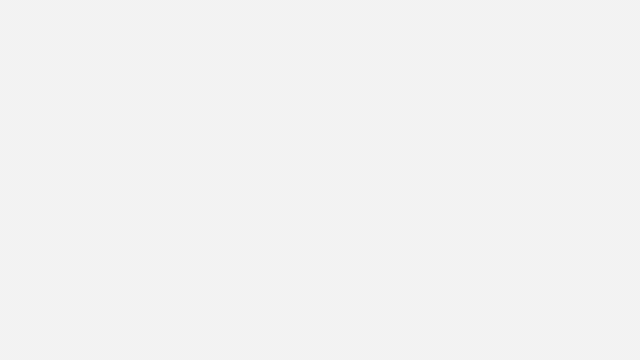

In [ ]:
from IPython.display import Image
Image(filename='../animations/gifs/svm_margin.gif')

In [3]:
class Support_Vector_Machine:
    def __init__(self, visualization=True):
        self.visualization = visualization
        self.colors = {1: '#eb6834', -1: '#2a78d6'}

    def fit(self, data):
        self.data = data
        opt_dict = {}

        # try w pointing in all four diagonal directions
        transforms = [[1, 1], [-1, 1], [-1, -1], [1, -1]]

        all_data = []
        for yi in self.data:
            for featureset in self.data[yi]:
                for feature in featureset:
                    all_data.append(feature)

        self.max_feature_value = max(all_data)
        self.min_feature_value = min(all_data)
        all_data = None

        # coarse pass first, then two finer ones
        step_sizes = [self.max_feature_value * 0.1,
                      self.max_feature_value * 0.01,
                      self.max_feature_value * 0.001]

        b_range_multiple = 5
        b_multiple = 5
        latest_optimum = self.max_feature_value * 10

        self.steps = []

        for step in step_sizes:
            w = np.array([latest_optimum, latest_optimum])
            optimized = False

            while not optimized:
                for b in np.arange(-1 * (self.max_feature_value * b_range_multiple),
                                   self.max_feature_value * b_range_multiple,
                                   step * b_multiple):
                    for transformation in transforms:
                        w_t = w * transformation
                        found_option = True

                        # every point has to satisfy y * (w . x + b) >= 1
                        for i in self.data:
                            for xi in self.data[i]:
                                yi = i
                                if not yi * (np.dot(w_t, xi) + b) >= 1:
                                    found_option = False
                                    break
                            if not found_option:
                                break

                        if found_option:
                            opt_dict[np.linalg.norm(w_t)] = [w_t, b]

                if w[0] < 0:
                    optimized = True
                else:
                    w = w - step

            # the smallest |w| that still fits every point is the widest margin
            norms = sorted([n for n in opt_dict])
            opt_choice = opt_dict[norms[0]]

            self.w = opt_choice[0]
            self.b = opt_choice[1]
            self.steps.append([step, np.linalg.norm(self.w)])

            latest_optimum = opt_choice[0][0] + step * 2

    def predict(self, features):
        # which side of the line the point falls on
        classification = np.sign(np.dot(np.array(features), self.w) + self.b)
        if classification != 0 and self.visualization:
            self.ax.scatter(features[0], features[1], s=200, marker='*',
                            c=self.colors[classification])
        return classification

    def visualize(self):
        # a fresh figure each time, so every plot in the notebook shows up
        self.fig = plt.figure(figsize=(8, 6.5))
        self.ax = self.fig.add_subplot(1, 1, 1)

        for i in self.data:
            for x in self.data[i]:
                self.ax.scatter(x[0], x[1], s=40, color=self.colors[i])

        # w . x + b = v, rearranged to give y back
        def hyperplane(x, w, b, v):
            return (-w[0] * x - b + v) / w[1]

        datarange = (self.min_feature_value * 0.9, self.max_feature_value * 1.1)
        hyp_x_min, hyp_x_max = datarange

        # the two margin lines
        for v, dash in [(1, '--'), (-1, '--'), (0, '-')]:
            p1 = hyperplane(hyp_x_min, self.w, self.b, v)
            p2 = hyperplane(hyp_x_max, self.w, self.b, v)
            self.ax.plot([hyp_x_min, hyp_x_max], [p1, p2], dash, color='k')

        # keep the view on the flowers rather than following the lines off-screen
        ys = [x[1] for i in self.data for x in self.data[i]]
        self.ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)

        self.ax.set_xlabel('petal length')
        self.ax.set_ylabel('petal width')
        self.ax.set_title('The boundary, the margin and the support vectors')

## Running it

The cell creates the classifier and calls `fit` on `data_dict`. The search tries a large number of
combinations, so this takes roughly 20 seconds. It then prints the `w` and `b` that were found,
the magnitude `|w|`, and the resulting margin width `2 / |w|`.

In [4]:
svm = Support_Vector_Machine()
svm.fit(data=data_dict)

print('w =', svm.w)
print('b =', round(svm.b, 3))
print('|w| =', round(np.linalg.norm(svm.w), 3))
print('margin width = 2/|w| =', round(2 / np.linalg.norm(svm.w), 3))

w = [1.1169 1.1169]
b = -3.57
|w| = 1.58
margin width = 2/|w| = 1.266


## Plotting the boundary and the margin

`margins` computes the **functional margin** $y_i\,(w \cdot x_i + b)$ for every point, which says
how far each one sits on its correct side. A value of 1 means the point is touching the margin
edge, and the constraint guarantees nothing is below that. Points with the smallest value are the
ones closest to the line, so `support` selects those within `0.05` of the minimum - the support
vectors.

The cell calls `visualize` to draw the points, the boundary (solid) and the two margin edges
(dashed), then adds hollow black circles on the support vectors. Only those circled points
determine where the line sits; the rest could be moved without changing it.

support vectors: 2 out of 100


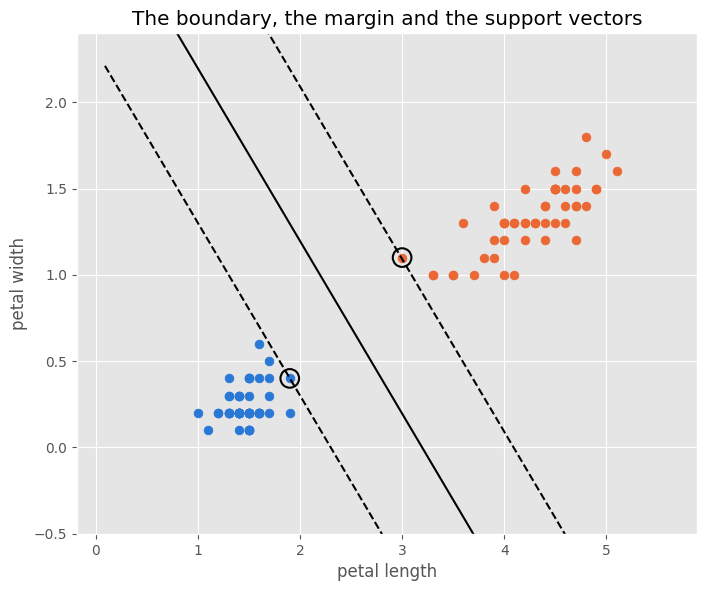

In [5]:
margins = y * (np.dot(X, svm.w) + svm.b)
support = margins <= margins.min() + 0.05

print('support vectors:', support.sum(), 'out of', len(X))

svm.visualize()
svm.ax.scatter(X[support, 0], X[support, 1], facecolors='none',
               edgecolors='k', s=180, linewidths=1.5)
plt.show()

## Classifying new points

`w` and `b` are fixed once `fit` has run, so `predict` can be called on measurements that were not
in the training data. The cell defines five new points and passes each to `predict`, which returns
`-1` or `+1` and plots the point as a star coloured by the result.

[1.5 0.3] -> -1 setosa
[4.5 1.4] -> 1 versicolor
[3. 1.] -> 1 versicolor
[5.  1.7] -> 1 versicolor
[1.  0.2] -> -1 setosa


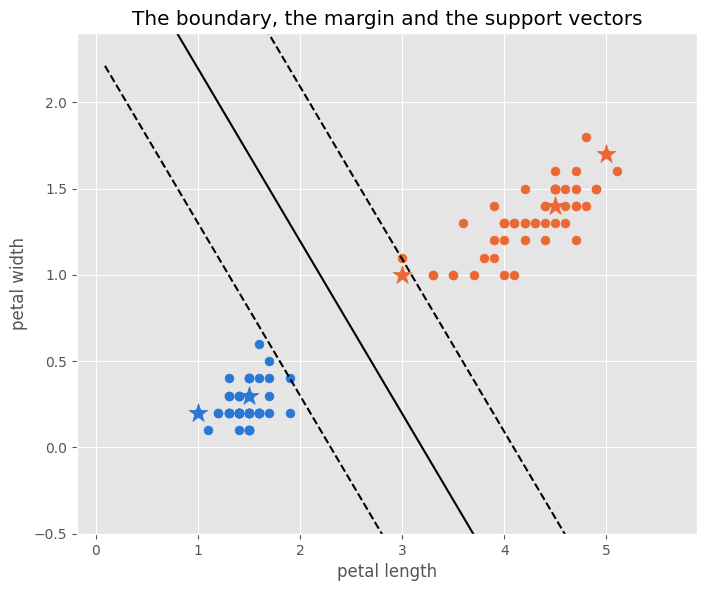

In [6]:
unknowns = np.array([[1.5, 0.3],
                     [4.5, 1.4],
                     [3.0, 1.0],
                     [5.0, 1.7],
                     [1.0, 0.2]])

svm.visualize()
for flower in unknowns:
    result = svm.predict(flower)
    name = 'setosa' if result == -1 else 'versicolor'
    print(flower, '->', int(result), name)
plt.show()

## Measuring accuracy

The cell sets `svm.visualization` to `False` first, because `predict` draws a star for every point
it is given and we are about to call it 100 times. It then runs `predict` across the whole dataset,
compares the results against `y`, and reports the totals for each species separately.

In [7]:
# turn the drawing off so we do not plot 100 stars
svm.visualization = False
predictions = np.array([svm.predict(x) for x in X])
svm.visualization = True

correct = (predictions == y).sum()
print(f'Correct: {correct} out of {len(X)}')
print(f'Accuracy: {correct / len(X)}')

setosa_correct = (predictions[y == -1] == -1).sum()
versicolor_correct = (predictions[y == 1] == 1).sum()
print()
print('setosa:    ', setosa_correct, '/', (y == -1).sum())
print('versicolor:', versicolor_correct, '/', (y == 1).sum())

Correct: 100 out of 100
Accuracy: 1.0

setosa:     50 / 50
versicolor: 50 / 50


## Accuracy graphs

`fit` recorded the step size and the resulting $\lVert w \rVert$ after each of its three passes in
`self.steps`. The cell converts each one into a margin width with $2 / \lVert w \rVert$ and plots
it against the pass number.

The margin widens on each pass because the finer step size lets the search find a slightly smaller
`|w|` than the coarser one could. Accuracy is 1.0 at every pass, since a candidate is only ever
accepted if it already classifies every point correctly - the search improves the margin, not the
number of correct answers.

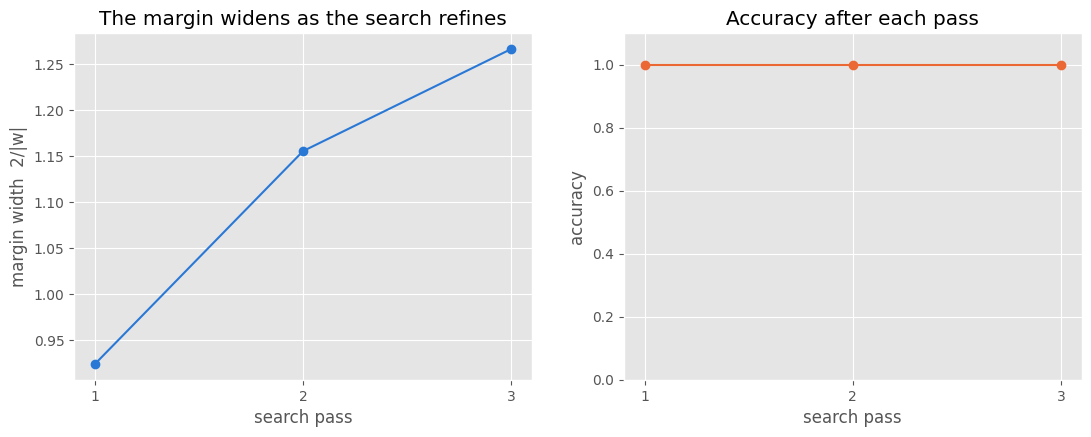

pass 1: step 0.5100  |w| 2.1637  margin 0.9243
pass 2: step 0.0510  |w| 1.7310  margin 1.1554
pass 3: step 0.0051  |w| 1.5795  margin 1.2662


In [8]:
steps = np.array(svm.steps)
widths = 2 / steps[:, 1]
accuracy_per_step = [1.0, 1.0, 1.0]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(range(1, 4), widths, marker='o', color='#2a78d6')
ax[0].set_xticks(range(1, 4))
ax[0].set_xlabel('search pass')
ax[0].set_ylabel('margin width  2/|w|')
ax[0].set_title('The margin widens as the search refines')

ax[1].plot(range(1, 4), accuracy_per_step, marker='o', color='#eb6834')
ax[1].set_xticks(range(1, 4))
ax[1].set_ylim(0, 1.1)
ax[1].set_xlabel('search pass')
ax[1].set_ylabel('accuracy')
ax[1].set_title('Accuracy after each pass')

plt.show()

for i, (step, norm) in enumerate(svm.steps):
    print(f'pass {i + 1}: step {step:.4f}  |w| {norm:.4f}  margin {2 / norm:.4f}')

## Distance of each point from the line

The cell plots a histogram of $y_i\,(w \cdot x_i + b)$ for every point, with the two species
separated by colour.

A value of exactly 1 means the point is touching the margin edge, and larger values mean it sits
further away. The dashed line marks 1. Nothing appears to the left of it, because

$$y_i\,(w \cdot x_i + b) \ge 1$$

is precisely the condition every accepted candidate had to satisfy. Dividing by $\lVert w \rVert$
converts these into actual distances: a point at 1 sits $1/\lVert w \rVert$ away from the boundary,
which is half the margin.

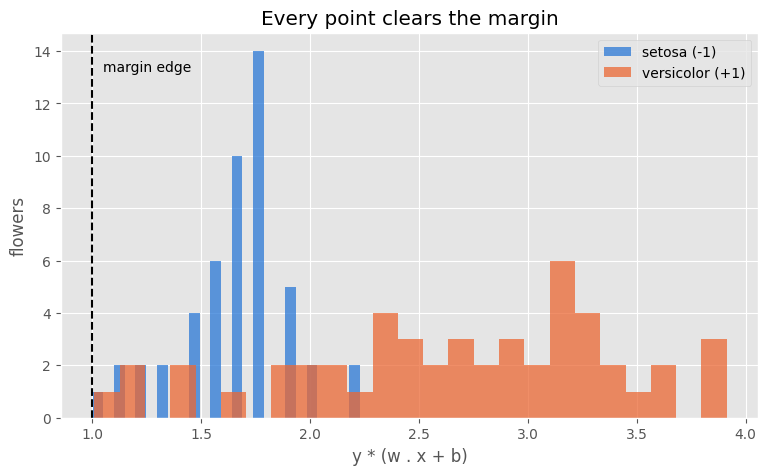

In [9]:
plt.figure(figsize=(9, 5))
plt.hist(margins[y == -1], bins=25, color='#2a78d6', alpha=0.75, label='setosa (-1)')
plt.hist(margins[y == 1], bins=25, color='#eb6834', alpha=0.75, label='versicolor (+1)')
plt.axvline(1, color='k', linestyle='--')
plt.text(1.05, plt.ylim()[1] * 0.9, 'margin edge', color='k')
plt.xlabel('y * (w . x + b)')
plt.ylabel('flowers')
plt.title('Every point clears the margin')
plt.legend()
plt.show()

## Summary

- The algorithm is a search for $\min \tfrac{1}{2}\lVert w \rVert^2$ subject to
  $y_i(w \cdot x_i + b) \ge 1$: reduce $w$, discard any value that breaks a constraint, keep the
  smallest that survives.
- $w$ sits at right angles to the boundary and its magnitude sets the margin width,
  $2 / \lVert w \rVert$.
- Only the support vectors determine the line. Every other point could be moved without affecting it.
- On `setosa` against `versicolor` it classifies all **100** flowers correctly, with a margin of 1.27.
- The search requires the two classes to be separable by a straight line, since it rejects any
  candidate that gets a single point wrong. That is why these two species were used.